# MNO: Multi-operator Network for PDE Learning

Self-contained notebook: **Data Generation** -> **Data Loading** -> **Model** -> **Training** -> **Testing**

PDE: Viscous conservation law $u_t + f(u)_x = \frac{\epsilon}{\pi} u_{xx}$, where $f(u) = k_1 u + \frac{k_2}{2} u^2 + \frac{k_3}{3} u^3$

In [1]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Configuration

In [2]:
# ============ Data / PDE config ============
DATA_DIR        = "dataset_simple/"   # where to save/load generated data
T_NUM           = 64                  # timesteps
X_NUM           = 128                 # spatial grid points
X_NUM_MODEL     = 64                  # subsampled spatial points for model
T_RANGE         = (0.0, 2.0)
X_RANGE         = (0.0, 2.0)
COEFF_NUM       = 4                   # [epsilon, k1, k2, k3]
INPUT_LEN       = 1                   # input timesteps
INPUT_STEP      = 1
OUTPUT_STEP     = 2
NORMALIZE       = True

# Generation parameters
N_PARAM_SETS    = 100                 # number of different PDE coefficient sets
ICS_PER_PARAM   = 20                  # initial conditions per coefficient set
TOTAL_SAMPLES   = N_PARAM_SETS * ICS_PER_PARAM  # 2000 total
TRAIN_SIZE      = 8000
EVAL_SIZE       = 2000

# PDE coefficient ranges (conservation law)
EPS_CENTER      = 0.1                 # diffusion coefficient center
FLUX_CENTER     = 1.0                 # flux coefficient center
PARAM_GAMMA     = 0.1                 # +/- 10% range

# ============ Model config ============
MODEL_NAME      = "MNO"             #  MNO, DeepONet
NUM_TRUNK       = 100
NUM_BRANCH      = 100
NUM_LEAF        = 100
HIDDEN_DIM      = 200
TRUNK_DEPTH     = 2
BRANCH_DEPTH    = 2
LEAF_DEPTH      = 2

# ============ Training config ============
BATCH_SIZE      = 128
BATCH_SIZE_EVAL = 256
MAX_EPOCHS      = 50
STEPS_PER_EPOCH = 500
LR              = 1e-4
WEIGHT_DECAY    = 1e-4
CLIP_GRAD_NORM  = 1.0
USE_AMP         = torch.cuda.is_available()
SEED            = 42
LOG_EVERY       = 50

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 2. Data Generation (Conservation Law PDE)

Finite-volume solver with:
- Van Leer slope limiter (2nd-order spatial reconstruction)
- Upwind flux + viscous diffusion
- Predictor-corrector time stepping
- Periodic boundary conditions
- Random sinusoidal initial conditions

In [3]:
# ---- Conservation law PDE solver (pure numpy, no JAX needed) ----

def generate_initial_conditions(xc, n_samples, rng, k_tot=4, n_modes=2):
    """Generate random sinusoidal initial conditions, normalized to [0, 1].
    Mimics the init_multi function from the original codebase."""
    nx = len(xc)
    x_len = xc[-1] - xc[0]
    u_all = np.zeros((n_samples, nx), dtype=np.float32)

    for i in range(n_samples):
        # Select random wavenumber modes
        selected_k = rng.choice(k_tot, size=n_modes, replace=False) + 1
        u = np.zeros(nx, dtype=np.float64)
        for k in selected_k:
            amp = rng.uniform(0, 1)
            phase = rng.uniform(0, 2 * np.pi)
            wavenumber = 2 * np.pi * k / x_len
            u += amp * np.sin(wavenumber * xc + phase)
        # Random sign flip
        if rng.random() < 0.5:
            u = -u
        # Remove linear trend for periodicity
        slope = (u[-1] - u[0]) / x_len
        u -= slope * xc
        # Normalize to [0, 1]
        u_min, u_max = u.min(), u.max()
        if u_max - u_min > 1e-10:
            u = (u - u_min) / (u_max - u_min)
        u_all[i] = u.astype(np.float32)
    return u_all


def solve_conservation_law(u0, epsilon, k1, k2, k3, x_range, t_range, nx, t_num, CFL=0.4):
    """Solve viscous conservation law: u_t + f(u)_x = (eps/pi) * u_xx
    with f(u) = k1*u + k2/2*u^2 + k3/3*u^3, periodic BCs.
    
    Returns: solution array of shape (t_num, nx)
    """
    dx = x_range / nx
    dx_inv = 1.0 / dx
    pi_inv = 1.0 / np.pi
    dt_save = t_range / (t_num - 1)

    def bc(u_in):
        """Apply periodic boundary conditions with 2 ghost cells on each side."""
        _u = np.zeros(nx + 4)
        _u[2:nx+2] = u_in
        _u[0:2] = u_in[-2:]    # left ghost
        _u[nx+2:nx+4] = u_in[0:2]  # right ghost
        return _u

    def vl_limiter(a, b, c, alpha=2.0):
        """Van Leer limiter."""
        return np.sign(c) * (0.5 + 0.5 * np.sign(a * b)) * \
               np.minimum(alpha * np.minimum(np.abs(a), np.abs(b)), np.abs(c))

    def limiting(_u):
        """2nd-order slope limiting."""
        duL = _u[1:nx+3] - _u[0:nx+2]
        duR = _u[2:nx+4] - _u[1:nx+3]
        duM = (_u[2:nx+4] - _u[0:nx+2]) * 0.5
        gradu = vl_limiter(duL, duR, duM)
        uL = np.zeros_like(_u)
        uR = np.zeros_like(_u)
        uL[1:nx+3] = _u[1:nx+3] - 0.5 * gradu
        uR[1:nx+3] = _u[1:nx+3] + 0.5 * gradu
        return uL, uR

    def compute_flux(u_tmp):
        """Compute numerical flux (upwind + diffusion)."""
        _u = bc(u_tmp)
        uL, uR = limiting(_u)
        # Polynomial flux: f(u) = k1*u + k2/2*u^2 + k3/3*u^3
        fL = k1 * uL + k2 * 0.5 * uL**2 + k3 * uL**3 / 3
        fR = k1 * uR + k2 * 0.5 * uR**2 + k3 * uR**3 / 3
        # Upwind flux
        f_upwd = 0.5 * (
            fR[1:nx+2] + fL[2:nx+3]
            - 0.5 * np.abs(uL[2:nx+3] + uR[1:nx+2]) * (uL[2:nx+3] - uR[1:nx+2])
        )
        # Diffusion
        f_upwd += -epsilon * pi_inv * (_u[2:nx+3] - _u[1:nx+2]) * dx_inv
        return f_upwd

    def update(u, u_tmp, dt):
        """One Euler step."""
        f = compute_flux(u_tmp)
        return u - dt * dx_inv * (f[1:nx+1] - f[0:nx])

    # Time integration
    u = u0.copy()
    uu = np.zeros((t_num, nx), dtype=np.float32)
    uu[0] = u

    t = 0.0
    i_save = 1
    t_save = dt_save

    while i_save < t_num:
        # Adaptive time step (CFL condition)
        dt_adv = dx / (np.max(np.abs(u)) + 1e-8) * CFL
        dt_dif = 0.5 * dx**2 / (epsilon * pi_inv + 1e-8) * CFL
        dt = min(dt_adv, dt_dif, t_save - t)
        if dt < 1e-12:
            break

        # Predictor-corrector
        u_tmp = update(u, u, dt * 0.5)
        u = update(u, u_tmp, dt)
        t += dt

        # Save at uniform time intervals
        if t >= t_save - 1e-10:
            uu[i_save] = u.astype(np.float32)
            i_save += 1
            t_save = i_save * dt_save

    return uu


def generate_conservation_dataset(data_dir, n_param_sets, ics_per_param,
                                   eps_center, flux_center, gamma,
                                   x_range, t_range, nx, t_num, seed=42):
    """
    Generate conservation law dataset and save to HDF5.
    Saves:
      - data_dir/solutions.h5: 'data' (N, t_num, nx, 1), 'coeffs' (N, 4)
    """
    os.makedirs(data_dir, exist_ok=True)
    h5_path = os.path.join(data_dir, "solutions.h5")

    rng = np.random.default_rng(seed)
    dx = x_range / nx
    xc = np.linspace(0, x_range, nx + 1)[:-1] + 0.5 * dx

    total = n_param_sets * ics_per_param
    all_solutions = np.zeros((total, t_num, nx, 1), dtype=np.float32)
    all_coeffs = np.zeros((total, 4), dtype=np.float32)
    idx = 0
    failed = 0

    for p in tqdm(range(n_param_sets), desc="Generating data"):
        # Sample PDE coefficients
        eps_half = abs(eps_center) * gamma
        epsilon = rng.uniform(eps_center - eps_half, eps_center + eps_half)
        flux_half = abs(flux_center) * gamma
        k = rng.uniform(flux_center - flux_half, flux_center + flux_half, size=3)
        coeff = np.array([epsilon, k[0], k[1], k[2]], dtype=np.float32)

        # Generate ICs for this parameter set
        ics = generate_initial_conditions(xc, ics_per_param * 2, rng)  # generate extra in case some fail

        count = 0
        for ic_idx in range(len(ics)):
            if count >= ics_per_param:
                break
            try:
                sol = solve_conservation_law(ics[ic_idx].astype(np.float64),
                                             epsilon, k[0], k[1], k[2],
                                             x_range, t_range, nx, t_num)
                norm = np.linalg.norm(sol)
                if norm < 2000 and norm > 1 and np.all(np.isfinite(sol)):
                    all_solutions[idx, :, :, 0] = sol
                    all_coeffs[idx] = coeff
                    idx += 1
                    count += 1
                else:
                    failed += 1
            except Exception:
                failed += 1


    # Trim to actual size
    all_solutions = all_solutions[:idx]
    all_coeffs = all_coeffs[:idx]

    # Save
    with h5py.File(h5_path, "w") as hf:
        hf.create_dataset("data", data=all_solutions)
        hf.create_dataset("coeffs", data=all_coeffs)

    print(f"Saved {idx} samples to {h5_path}")
    return h5_path

In [4]:
# Generate or load data
h5_path = os.path.join(DATA_DIR, "solutions.h5")

if os.path.exists(h5_path):
    print(f"Data already exists at {h5_path}, loading...")
    with h5py.File(h5_path, "r") as hf:
        print(f"  Solutions shape: {hf['data'].shape}")
        print(f"  Coefficients shape: {hf['coeffs'].shape}")
else:
    print("Generating conservation law dataset...")
    generate_conservation_dataset(
        DATA_DIR, N_PARAM_SETS, ICS_PER_PARAM,
        EPS_CENTER, FLUX_CENTER, PARAM_GAMMA,
        X_RANGE[1], T_RANGE[1], X_NUM, T_NUM, seed=SEED
    )

Data already exists at dataset_simple/solutions.h5, loading...
  Solutions shape: (2000, 64, 128, 1)
  Coefficients shape: (2000, 4)


## 3. Dataset & DataLoader

In [5]:
class ConservationDataset(Dataset):
    """Load solutions and coefficients from a single HDF5 file."""

    def __init__(self, h5_path, indices, t_range, x_range, t_num, x_num, noise=0.0, train=True):
        super().__init__()
        self.noise = noise
        self.train = train
        self.rng = np.random.default_rng(SEED + (0 if train else 100))

        with h5py.File(h5_path, "r") as hf:
            self.solutions = hf["data"][indices]    # (N, t_num, x_num, 1)
            self.coeffs = hf["coeffs"][indices]     # (N, 4)

        self.t_grid = np.linspace(t_range[0], t_range[1], t_num + 1)[:-1].astype(np.float32)
        dx = (x_range[1] - x_range[0]) / x_num
        self.x_grid = (np.linspace(x_range[0], x_range[1], x_num + 1)[:-1] + 0.5 * dx).astype(np.float32)

        print(f"Dataset: {len(self.solutions)} samples ({'train' if train else 'eval'})")

    def __len__(self):
        return len(self.solutions)

    def __getitem__(self, idx):
        sol = self.solutions[idx].copy()  # (t_num, x_num, 1)
        if self.noise > 0 and self.train:
            noise = self.rng.normal(size=sol.shape).astype(np.float32)
            sigma = self.noise * np.linalg.norm(sol) / (np.linalg.norm(noise) + 1e-6)
            sol = sol + sigma * noise
        return {
            "data": torch.from_numpy(sol),
            "t": torch.from_numpy(self.t_grid),
            "x": torch.from_numpy(self.x_grid),
            "coeff": torch.from_numpy(self.coeffs[idx]),
        }


def collate_fn(batch):
    return {
        "data":  torch.stack([b["data"] for b in batch]),
        "t":     torch.stack([b["t"] for b in batch]),
        "x":     torch.stack([b["x"] for b in batch]),
        "coeff": torch.stack([b["coeff"] for b in batch]),
    }

In [6]:
# Check available data size and create train/eval split
with h5py.File(h5_path, "r") as hf:
    n_total = hf["data"].shape[0]
print(f"Total samples available: {n_total}")

train_size = min(TRAIN_SIZE, int(0.8 * n_total))
eval_size = min(EVAL_SIZE, n_total - train_size)

train_indices = list(range(train_size))
eval_indices = list(range(train_size, train_size + eval_size))

train_dataset = ConservationDataset(h5_path, train_indices, T_RANGE, X_RANGE, T_NUM, X_NUM, noise=0.02, train=True)
eval_dataset = ConservationDataset(h5_path, eval_indices, T_RANGE, X_RANGE, T_NUM, X_NUM, noise=0.0, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, collate_fn=collate_fn)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE_EVAL, shuffle=False, collate_fn=collate_fn)

# Inspect a batch
batch = next(iter(train_loader))
for k, v in batch.items():
    print(f"{k}: shape={v.shape}, dtype={v.dtype}")

Total samples available: 2000
Dataset: 1600 samples (train)
Dataset: 400 samples (eval)
data: shape=torch.Size([128, 64, 128, 1]), dtype=torch.float32
t: shape=torch.Size([128, 64]), dtype=torch.float32
x: shape=torch.Size([128, 128]), dtype=torch.float32
coeff: shape=torch.Size([128, 4]), dtype=torch.float32


## 4. Model Architectures

In [7]:
def build_mlp(in_dim, out_dim, hidden_dim, depth):
    layers = []
    d = in_dim
    for _ in range(depth - 1):
        layers += [nn.Linear(d, hidden_dim), nn.ReLU()]
        d = hidden_dim
    layers.append(nn.Linear(d, out_dim))
    return nn.Sequential(*layers)


class MNO(nn.Module):
    """MNO variant: leaf-first contraction."""
    def __init__(self, x_num, input_len, coeff_num, num_trunk=100, num_branch=100, num_leaf=100,
                 hidden_dim=200, trunk_depth=2, branch_depth=2, leaf_depth=2):
        super().__init__()
        self.num_trunk, self.num_branch, self.num_leaf, self.x_num = num_trunk, num_branch, num_leaf, x_num
        self.trunk = build_mlp(2, num_leaf * num_trunk, hidden_dim, trunk_depth)
        self.branch = build_mlp(x_num * input_len, num_leaf * num_trunk * num_branch, hidden_dim, branch_depth)
        self.leaf = build_mlp(coeff_num, num_leaf, hidden_dim, leaf_depth)
        self.const = nn.Parameter(torch.randn(num_leaf, num_trunk, num_branch))
        self.g = nn.ReLU()

    def forward(self, data_input, query_time, query_space_grid, coeff):
        bs, num_t = data_input.size(0), query_time.size(1)
        t_exp = query_time.expand(-1, -1, query_space_grid.size(1))
        x_exp = query_space_grid.transpose(1, 2).expand(-1, num_t, -1)
        y = torch.stack([t_exp, x_exp], dim=-1).view(bs, -1, 2)
        d = y.size(1)
        c_out = self.g(self.leaf(coeff).view(bs, self.num_leaf))
        y_out = self.g(self.trunk(y.view(-1, 2)).view(bs, d, self.num_leaf, self.num_trunk))
        u_out = self.g(self.branch(data_input.view(bs, -1)).view(bs, self.num_leaf, self.num_trunk, self.num_branch))
        result = torch.einsum('bl,bdlt,bltk,ltk->bd', c_out, y_out, u_out, self.const)
        return result.view(bs, num_t, self.x_num, -1)


class DeepONet(nn.Module):
    """DeepONet: trunk(t,x) * branch(u||c) * const."""
    def __init__(self, x_num, input_len, coeff_num, num_trunk=100, num_branch=100,
                 hidden_dim=200, trunk_depth=2, branch_depth=2, **kw):
        super().__init__()
        self.num_trunk, self.num_branch, self.x_num = num_trunk, num_branch, x_num
        self.trunk = build_mlp(2, num_trunk, hidden_dim, trunk_depth)
        self.branch = build_mlp(x_num * input_len + coeff_num, num_trunk * num_branch, hidden_dim, branch_depth)
        self.const = nn.Parameter(torch.randn(num_trunk, num_branch))
        self.g = nn.ReLU()

    def forward(self, data_input, query_time, query_space_grid, coeff):
        bs, num_t = data_input.size(0), query_time.size(1)
        t_exp = query_time.expand(-1, -1, query_space_grid.size(1))
        x_exp = query_space_grid.transpose(1, 2).expand(-1, num_t, -1)
        y = torch.stack([t_exp, x_exp], dim=-1).view(bs, -1, 2)
        y_out = self.g(self.trunk(y.view(-1, 2)).view(bs, -1, self.num_trunk))
        u = torch.cat([coeff, data_input.view(bs, -1)], dim=1)
        u_out = self.g(self.branch(u).view(bs, self.num_trunk, self.num_branch))
        result = torch.einsum('bdt,btk,tk->bd', y_out, u_out, self.const)
        return result.view(bs, num_t, self.x_num, -1)


In [8]:
# Build model
input_len = INPUT_LEN // INPUT_STEP
kw = dict(x_num=X_NUM_MODEL, input_len=input_len, coeff_num=COEFF_NUM,
          num_trunk=NUM_TRUNK, num_branch=NUM_BRANCH, hidden_dim=HIDDEN_DIM,
          trunk_depth=TRUNK_DEPTH, branch_depth=BRANCH_DEPTH)

if MODEL_NAME in ("MONet", "MNO"):
    kw.update(num_leaf=NUM_LEAF, leaf_depth=LEAF_DEPTH)
model = { "MNO": MNO, "DeepONet": DeepONet}[MODEL_NAME](**kw).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME} | Parameters: {n_params:,}")

Model: MNO | Parameters: 204,044,700


## 5. Training Utilities

In [9]:
def prepare_batch(batch):
    """Split data into input/output, subsample spatially, normalize."""
    data = batch["data"]        # (bs, t_num, x_num, 1)
    t = batch["t"]              # (bs, t_num)
    x = batch["x"]              # (bs, x_num)
    coeff = batch["coeff"]      # (bs, 4)

    # Spatial subsampling
    x_idx = torch.linspace(0, X_NUM - 1, steps=X_NUM_MODEL, dtype=torch.long)
    x_sample = x[:, x_idx]

    # Temporal split
    data_input = data[:, 0:INPUT_LEN:INPUT_STEP, x_idx]          # (bs, input_len, x_model, 1)
    data_label = data[:, INPUT_LEN:T_NUM:OUTPUT_STEP, x_idx]     # (bs, output_len, x_model, 1)
    output_times = t[:, INPUT_LEN:T_NUM:OUTPUT_STEP]

    # To device
    data_input = data_input.to(device)
    data_label = data_label.to(device)
    output_times = output_times.to(device)
    x_sample = x_sample.to(device)
    coeff = coeff.to(device)

    # Normalize per sample
    if NORMALIZE:
        mean = data_input.mean(dim=(1, 2), keepdim=True)
        std = data_input.std(dim=(1, 2), keepdim=True)
        eps = 1e-6
        data_input = (data_input - mean) / (std + eps)
        data_label = (data_label - mean) / (std + eps)
    else:
        mean, std = 0, 1

    return dict(data_input=data_input, data_label=data_label,
                output_times=output_times, spatial_grid=x_sample,
                coeff=coeff, mean=mean, std=std)

## 6. Training Loop

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, eps=1e-6)
total_steps = MAX_EPOCHS * STEPS_PER_EPOCH
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

print(f"Training: {MAX_EPOCHS} epochs x {STEPS_PER_EPOCH} steps = {total_steps} total steps")

Training: 50 epochs x 500 steps = 25000 total steps


In [11]:
train_losses, eval_l2_errors = [], []
best_l2, best_state = float('inf'), None

for epoch in range(MAX_EPOCHS):
    # ---- Train ----
    model.train()
    epoch_loss = 0.0
    data_iter = iter(train_loader)

    for step in range(STEPS_PER_EPOCH):
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            batch = next(data_iter)

        d = prepare_batch(batch)
        with torch.amp.autocast('cuda', enabled=USE_AMP, dtype=torch.bfloat16):
            output = model(data_input=d["data_input"],
                           query_time=d["output_times"][..., None],
                           query_space_grid=d["spatial_grid"][..., None],
                           coeff=d["coeff"])
            loss = F.mse_loss(output, d["data_label"])

        optimizer.zero_grad()
        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
            optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

        if (step + 1) % LOG_EVERY == 0:
            print(f"  Epoch {epoch} | Step {step+1}/{STEPS_PER_EPOCH} | Loss: {epoch_loss/(step+1):.6f}")

    avg_loss = epoch_loss / STEPS_PER_EPOCH
    train_losses.append(avg_loss)

    # ---- Eval ----
    model.eval()
    all_l2 = []
    with torch.no_grad():
        for batch in eval_loader:
            d = prepare_batch(batch)
            with torch.amp.autocast('cuda', enabled=USE_AMP, dtype=torch.bfloat16):
                output = model(data_input=d["data_input"],
                               query_time=d["output_times"][..., None],
                               query_space_grid=d["spatial_grid"][..., None],
                               coeff=d["coeff"])
            # Denormalize for metrics
            if NORMALIZE:
                eps = 1e-6
                output = output * (d["std"] + eps) + d["mean"]
                label = d["data_label"] * (d["std"] + eps) + d["mean"]
            else:
                label = d["data_label"]
            err = torch.sqrt(((label - output)**2).flatten(1).sum(1))
            scl = 1e-7 + torch.sqrt((label**2).flatten(1).sum(1))
            all_l2.extend((err / scl).cpu().tolist())

    mean_l2 = np.mean(all_l2)
    eval_l2_errors.append(mean_l2)

    if mean_l2 < best_l2:
        best_l2 = mean_l2
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  >> New best! Rel L2: {mean_l2:.6f}")

    print(f"Epoch {epoch} | Train Loss: {avg_loss:.6f} | Eval Rel L2: {mean_l2:.6f}\n")

  Epoch 0 | Step 50/500 | Loss: 27.472224
  Epoch 0 | Step 100/500 | Loss: 14.683155
  Epoch 0 | Step 150/500 | Loss: 10.106101
  Epoch 0 | Step 200/500 | Loss: 7.703547
  Epoch 0 | Step 250/500 | Loss: 6.212085
  Epoch 0 | Step 300/500 | Loss: 5.200019
  Epoch 0 | Step 350/500 | Loss: 4.472782
  Epoch 0 | Step 400/500 | Loss: 3.926563
  Epoch 0 | Step 450/500 | Loss: 3.500100
  Epoch 0 | Step 500/500 | Loss: 3.158995
  >> New best! Rel L2: 0.157068
Epoch 0 | Train Loss: 3.158995 | Eval Rel L2: 0.157068

  Epoch 1 | Step 50/500 | Loss: 0.073470
  Epoch 1 | Step 100/500 | Loss: 0.070407
  Epoch 1 | Step 150/500 | Loss: 0.067962
  Epoch 1 | Step 200/500 | Loss: 0.064885
  Epoch 1 | Step 250/500 | Loss: 0.062881
  Epoch 1 | Step 300/500 | Loss: 0.060598
  Epoch 1 | Step 350/500 | Loss: 0.058791
  Epoch 1 | Step 400/500 | Loss: 0.057007
  Epoch 1 | Step 450/500 | Loss: 0.055792
  Epoch 1 | Step 500/500 | Loss: 0.054242
  >> New best! Rel L2: 0.114928
Epoch 1 | Train Loss: 0.054242 | Eval R

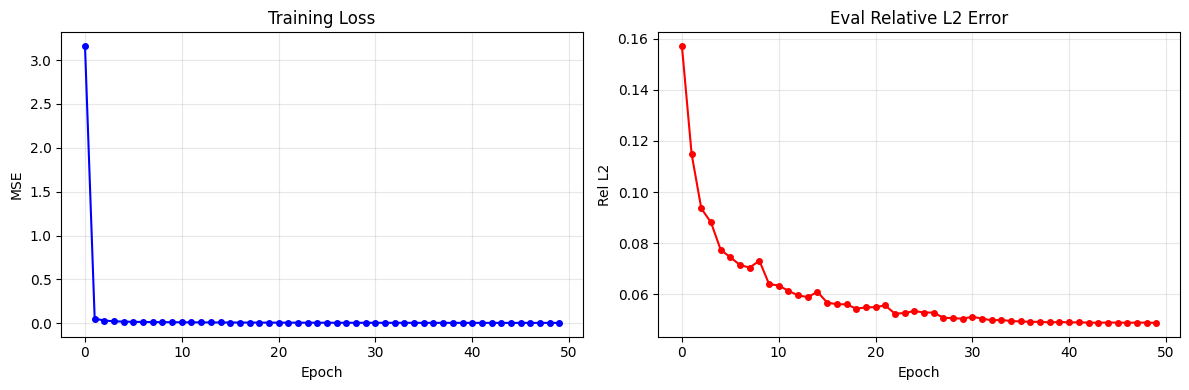

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, 'b-o', ms=4); ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE'); ax1.set_title('Training Loss'); ax1.grid(alpha=0.3)
ax2.plot(eval_l2_errors, 'r-o', ms=4); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Rel L2'); ax2.set_title('Eval Relative L2 Error'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Testing & Evaluation

In [13]:
def evaluate_model(model, loader):
    model.eval()
    results = defaultdict(list)
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            d = prepare_batch(batch)
            with torch.amp.autocast('cuda', enabled=USE_AMP, dtype=torch.bfloat16):
                output = model(data_input=d["data_input"],
                               query_time=d["output_times"][..., None],
                               query_space_grid=d["spatial_grid"][..., None],
                               coeff=d["coeff"])
            if NORMALIZE:
                eps = 1e-6
                output = output * (d["std"] + eps) + d["mean"]
                label = d["data_label"] * (d["std"] + eps) + d["mean"]
            else:
                label = d["data_label"]

            seq = output.size(1)
            h = seq // 2
            for name, p, l in [("rel_l2", output, label),
                               ("rel_l2_1st", output[:,:h], label[:,:h]),
                               ("rel_l2_2nd", output[:,h:], label[:,h:])]:
                e = torch.sqrt(((l-p)**2).flatten(1).sum(1))
                s = 1e-7 + torch.sqrt((l**2).flatten(1).sum(1))
                results[name].extend((e/s).cpu().tolist())

            mse = ((output-label)**2).flatten(1).mean(1)
            results["mse"].extend(mse.cpu().tolist())
            results["rmse"].extend(torch.sqrt(mse).cpu().tolist())
            all_preds.append(output.cpu()); all_labels.append(label.cpu())

    metrics = {k: np.mean(v) for k, v in results.items()}
    P = torch.cat(all_preds).reshape(len(results["mse"]), -1).numpy()
    L = torch.cat(all_labels).reshape(len(results["mse"]), -1).numpy()
    metrics["r2"] = r2_score(L, P)
    return metrics, torch.cat(all_preds), torch.cat(all_labels)

In [14]:
# Load best model and evaluate
if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)

metrics, preds, labels = evaluate_model(model, eval_loader)

print(f"{'='*50}")
print(f"Final Evaluation: {MODEL_NAME} on conservation law")
print(f"{'='*50}")
print(f"  Relative L2 Error:  {metrics['rel_l2']:.6f}")
print(f"  Rel L2 (1st half):  {metrics['rel_l2_1st']:.6f}")
print(f"  Rel L2 (2nd half):  {metrics['rel_l2_2nd']:.6f}")
print(f"  MSE:                {metrics['mse']:.6e}")
print(f"  RMSE:               {metrics['rmse']:.6e}")
print(f"  R2 Score:           {metrics['r2']:.6f}")

Final Evaluation: MNO on conservation law
  Relative L2 Error:  0.048873
  Rel L2 (1st half):  0.053149
  Rel L2 (2nd half):  0.042007
  MSE:                7.824890e-04
  RMSE:               2.548073e-02
  R2 Score:           0.932680


## 8. Visualization

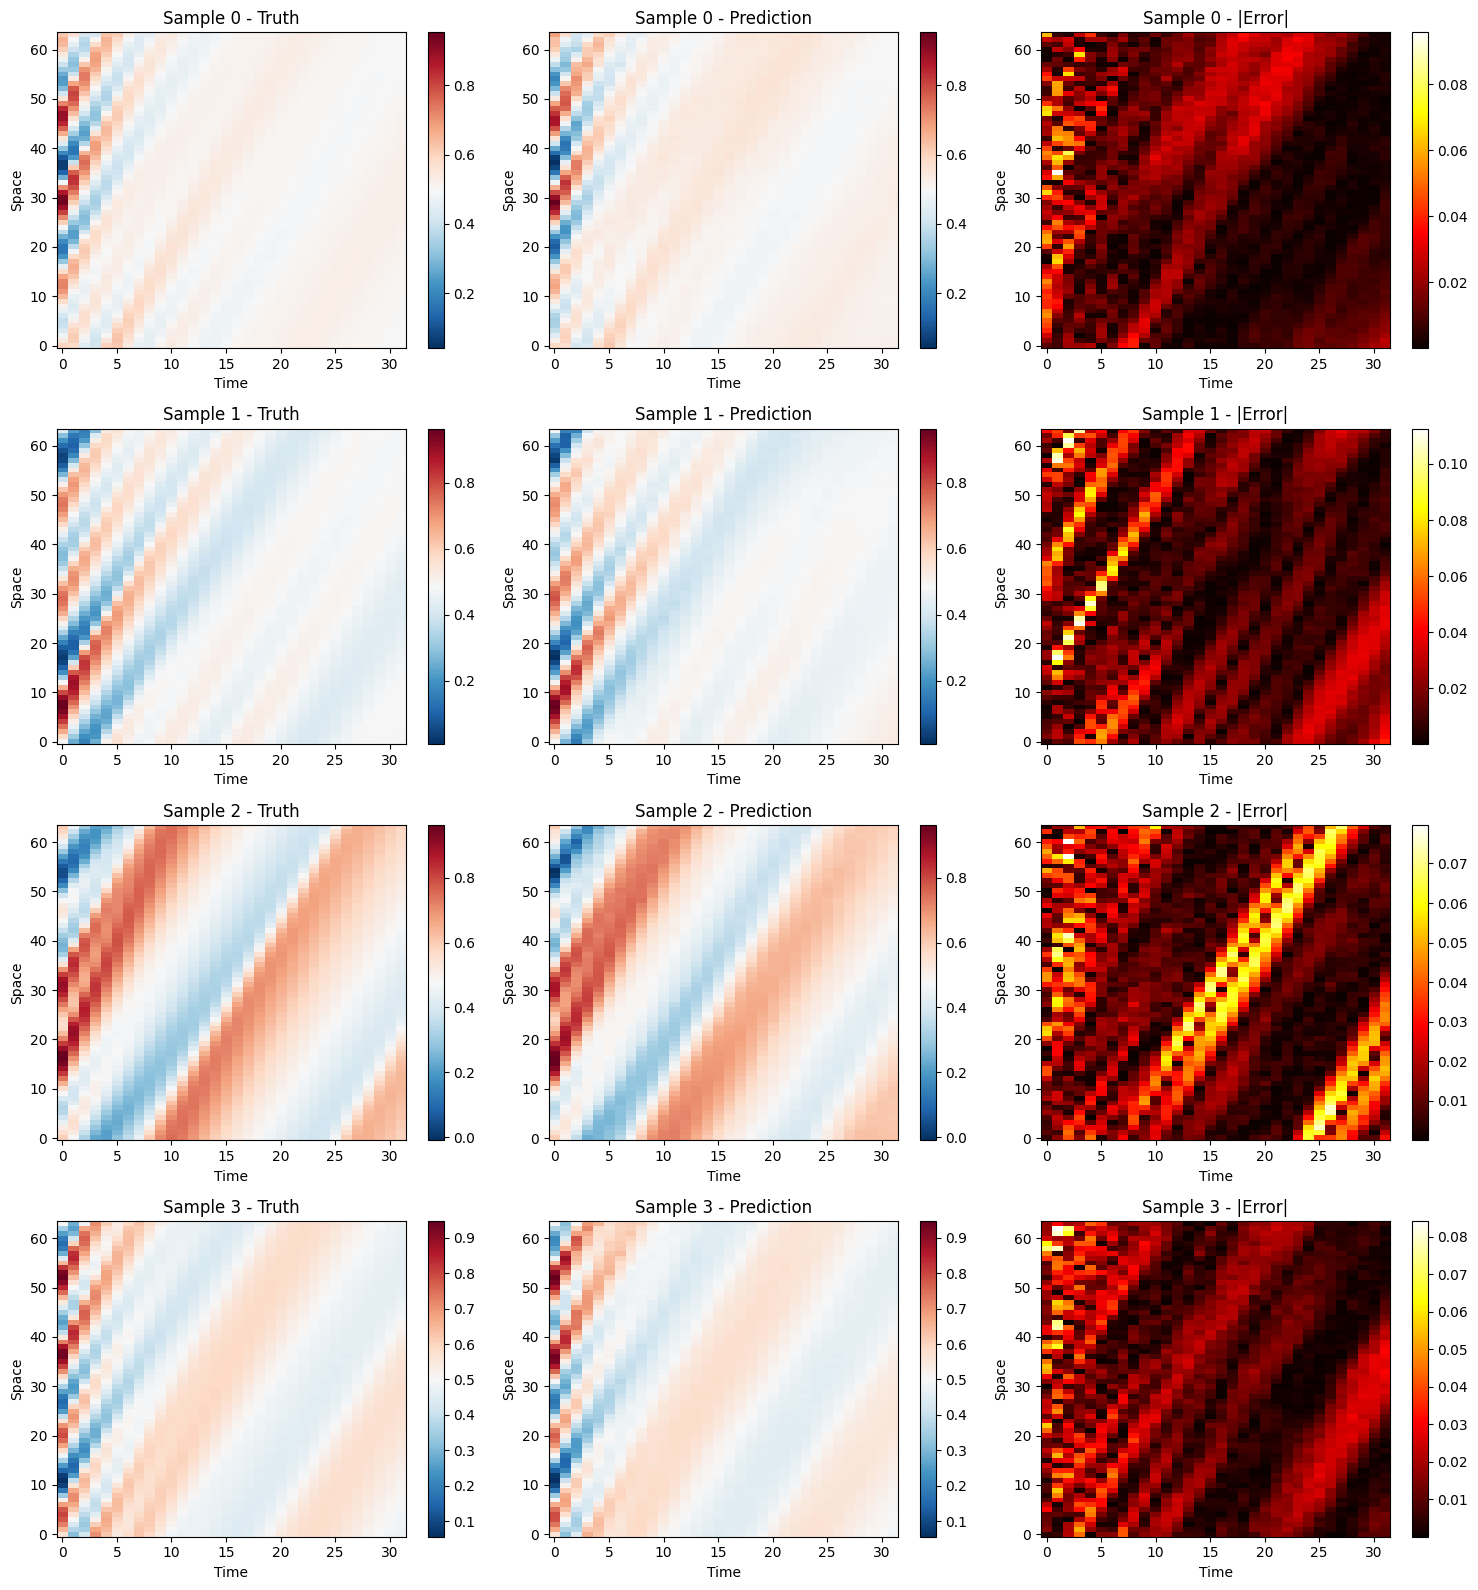

In [15]:
def plot_samples(preds, labels, n=4):
    n = min(n, preds.size(0))
    fig, axes = plt.subplots(n, 3, figsize=(15, 4*n))
    if n == 1: axes = axes[None, :]
    for i in range(n):
        p, l = preds[i,:,:,0].numpy(), labels[i,:,:,0].numpy()
        vmin, vmax = min(p.min(), l.min()), max(p.max(), l.max())
        for j, (arr, title) in enumerate([(l, 'Truth'), (p, 'Prediction'), (np.abs(p-l), '|Error|')]):
            cm = 'hot' if j == 2 else 'RdBu_r'
            kw = {} if j == 2 else dict(vmin=vmin, vmax=vmax)
            im = axes[i,j].imshow(arr.T, aspect='auto', origin='lower', cmap=cm, **kw)
            axes[i,j].set_title(f'Sample {i} - {title}')
            axes[i,j].set_xlabel('Time'); axes[i,j].set_ylabel('Space')
            plt.colorbar(im, ax=axes[i,j])
    plt.tight_layout(); plt.show()

plot_samples(preds, labels, n=4)

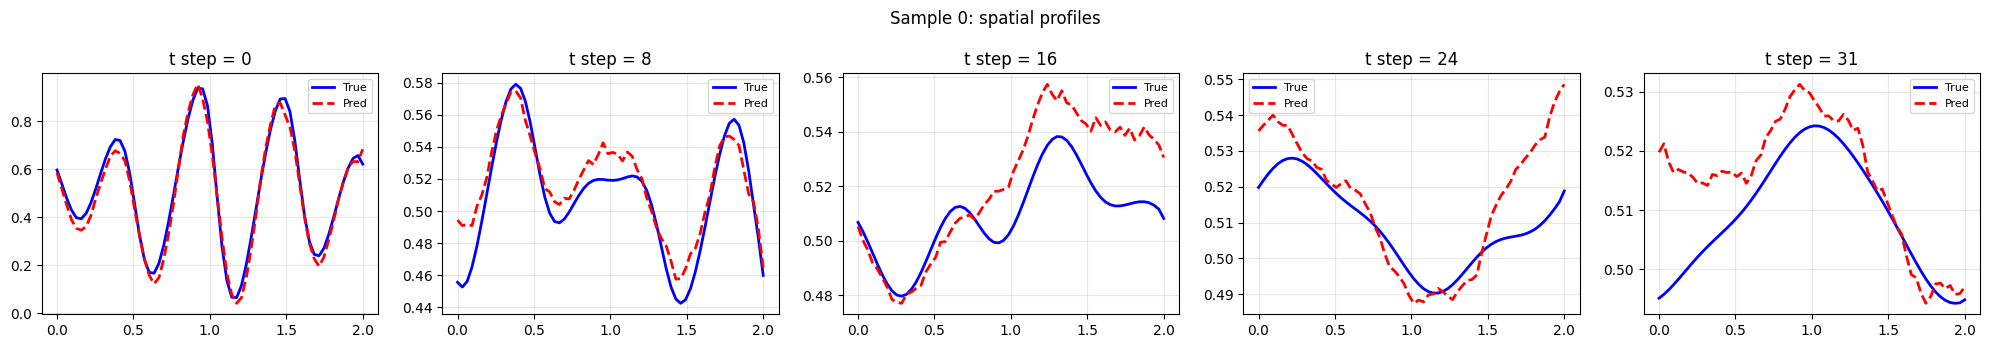

In [16]:
def plot_slices(preds, labels, sample=0):
    p, l = preds[sample,:,:,0].numpy(), labels[sample,:,:,0].numpy()
    nt = p.shape[0]
    steps = [0, nt//4, nt//2, 3*nt//4, nt-1]
    x = np.linspace(X_RANGE[0], X_RANGE[1], X_NUM_MODEL)
    fig, axes = plt.subplots(1, len(steps), figsize=(4*len(steps), 3.5))
    for i, t in enumerate(steps):
        axes[i].plot(x, l[t], 'b-', lw=2, label='True')
        axes[i].plot(x, p[t], 'r--', lw=2, label='Pred')
        axes[i].set_title(f't step = {t}'); axes[i].legend(fontsize=8); axes[i].grid(alpha=0.3)
    plt.suptitle(f'Sample {sample}: spatial profiles'); plt.tight_layout(); plt.show()

plot_slices(preds, labels, sample=0)

## 9. Save Model

In [17]:
save_path = f"best_{MODEL_NAME}_conservation.pth"
torch.save({"model": best_state or model.state_dict(), "metrics": metrics}, save_path)
print(f"Saved to {save_path}")

# Download to local machine (Colab only)
from google.colab import files
files.download(save_path)

Saved to best_MNO_conservation.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>